In [1]:
import warnings

warnings.filterwarnings("ignore")

# for interactive 
from itables import init_notebook_mode
init_notebook_mode(all_interactive = True)
import itables.options as opt
opt.maxBytes = 2**20
opt.maxColumns= 0

from datetime import date, timedelta
from pypfopt import expected_returns
import pyfolio as pf
import ffn
import timebudget 
from empyrical.stats import  *

<IPython.core.display.Javascript object>

In [2]:
cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [3]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPortfolioSelection import *
from myPortfolioManagement.myPortfolioOptimisation import *
from myPortfolioManagement.myPerformanceMetrics import *
from myPortfolioManagement.myReturns import *
from myPortfolioManagement.myBacktesting import *

### Compare my initial Allocation with optimisers

In [4]:
# isin of initial funds 

# Baillie Gifford China Class B - Accumulation (GBP)
# Rathbone Global Opportunities Class S - Accumulation (GBP)
# Scottish Mortgage Investment Trust plc Ordinary Shares 5p
# Royal London Sustainable Diversified Trust
# Vanguard FTSE 250 UCITS ETF (VMID)
# Baillie Gifford Global Discovery Fund B Accumulation
# Pictet - Global Environmental Opportunities I dy GBP
# Baillie Gifford Positive Change Fund
# Baillie Gifford European Fund B Accumulation
# BlackRock Global Funds - World Technology Fund D2 GBP Acc
# iShares Physical Gold ETC (SGLN)


myFunds = ['GB00B39RMM81','GB00B8HKW798', 'GB00BYVGKV59', 'GB0006059330','LU0503631631',   
           'GB0006058258', 'LU0827890491'] 
myStocks = ['SMT.L', '0P0001FE43.L', 'SGLN.L', 'VMID.L', '0P00016NZ4.L']


In [5]:
# download from Yahoo 
# Set dates 
start_date = '2017-01-01'
end_date = date.today() -  timedelta(days=1)
end_date = end_date.strftime("%Y-%m-%d") 

df_myfunds = get_mutual_funds_prices(mutual_fund_isin = myFunds, 
                        start_date = start_date , 
                        end_date = end_date, 
                        num_cpus=5)

NameError: name 'get_mutual_funds_prices' is not defined

In [7]:
df_stocks = get_stock_prices(yahoo_tickers = myStocks, 
                 start_date = start_date,
                 end_date = end_date, 
                 time_interval = 'daily') 

get_stock_prices took 1.718sec


In [9]:
df_stocks.tail(10)

high         low        open       close  volume  \
Date                                                                 
2023-11-21  224.399994  224.399994  224.399994  224.399994       0   
2023-11-22  225.199997  225.199997  225.199997  225.199997       0   
2023-11-23  224.899994  224.899994  224.899994  224.899994       0   
2023-11-24  224.600006  224.600006  224.600006  224.600006       0   
2023-11-27  224.800003  224.800003  224.800003  224.800003       0   
2023-11-28  224.199997  224.199997  224.199997  224.199997       0   
2023-11-29  224.199997  224.199997  224.199997  224.199997       0   
2023-11-30  224.800003  224.800003  224.800003  224.800003       0   
2023-12-01  225.300003  225.300003  225.300003  225.300003       0   
2023-12-04  225.899994  225.899994  225.899994  225.899994       0   

              adjclose   yahooTicker instrumentType  
Date                                                 
2023-11-21  224.399994  0P00016NZ4.L     MUTUALFUND  
2023-11-22  225.199997  0P00016NZ4.L     MUTUALFUND  
2023-11-23  224.899994  0P00016NZ4.L     MUTUALFUND  
2023-11-24  224.600006  0P00016NZ4.L     MUTUALFUND  
2023-11-27  224.800003  0P00016NZ4.L     MUTUALFUND  
2023-11-28  224.199997  0P00016NZ4.L     MUTUALFUND  
2023-11-29  224.199997  0P00016NZ4.L     MUTUALFUND  
2023-11-30  224.800003  0P00016NZ4.L     MUTUALFUND  
2023-12-01  225.300003  0P00016NZ4.L     MUTUALFUND  
2023-12-04  225.899994  0P00016NZ4.L     MUTUALFUND

In [11]:
df_stocks = df_stocks[['yahooTicker', 'adjclose']].rename(columns = {'yahooTicker':'fund'})
#df_myfunds = df_myfunds[['fund', 'adjclose']]

In [12]:
#df = pd.concat([df_myfunds, df_stocks ])
df = df_stocks

In [16]:
df_stocks.fund.drop_duplicates()

Date
2017-01-03          SGLN.L
2018-01-02    0P0001FE43.L
2017-01-03          VMID.L
2017-01-03           SMT.L
2018-01-02    0P00016NZ4.L
Name: fund, dtype: object

In [13]:
# from long to wide 
df_cleaned = df.pivot_table(index=['Date'], 
                        columns='fund', 
                        values='adjclose')

# slice 
df_cleaned = df_cleaned[ df_cleaned.index>= '2017-01-01']
df_cleaned.index = pd.to_datetime(df_cleaned.index, infer_datetime_format = True)

# full Dataframe with Returns Cleaned
df_returns = expected_returns.returns_from_prices(df_cleaned.interpolate(method = "time")) 

In [20]:
#d = {'fund':df_returns.columns.to_list(), 
#     'myPortfolio':[0.10,0.06,0.06,0.07,0.04,0.06,0.08,0.10,0.20,0.12,0.11]}
# df_myportfolio = pd.DataFrame(d)

d = {'fund':df_returns.columns.to_list(), 
     'myPortfolio':[1/5,1/5,1/5,1/5, 1/5]}
df_myportfolio = pd.DataFrame(d)
df_myportfolio

fund  myPortfolio
0  0P00016NZ4.L          0.2
1  0P0001FE43.L          0.2
2        SGLN.L          0.2
3         SMT.L          0.2
4        VMID.L          0.2

In [21]:
'''
Baillie Gifford China Class B - Accumulation (GBP)	10%
Rathbone Global Opportunities Class S - Accumulation (GBP)	10%
Scottish Mortgage Investment Trust plc Ordinary Shares 5p	12%
Royal London Sustainable Diversified Trust	20%
Vanguard FTSE 250 UCITS ETF (VMID)	11%
Baillie Gifford Positive Change Fund	7%
Baillie Gifford Global Discovery Fund B Accumulation	6%
Pictet - Global Environmental Opportunities I dy GBP	8%
Baillie Gifford European Fund B Accumulation	6%
BlackRock Global Funds - World Technology Fund D2 GBP Acc	4%
iShares Physical Gold ETC (SGLN)	6%
### my portfolio returns 
df_initial_port_returns = calculate_portfolio_returns(df_returns,df_returns.columns.to_list(),
                            [0.10,0.06,0.06,0.07,0.04,0.06,0.08,0.10,0.20,0.12,0.11], 
                            portfolio_name = 'myPortfolio')
'''

df_initial_port_returns = calculate_portfolio_returns(df_returns, df_myportfolio, portfolio_name = 'myPortfolio')

In [22]:
df_initial_port_returns

myPortfolio
Date                  
2017-01-04   -0.000041
2017-01-05    0.003767
2017-01-06    0.003447
2017-01-09    0.008794
2017-01-10    0.004599
...                ...
2023-11-28   -0.000108
2023-11-29    0.003108
2023-11-30    0.000072
2023-12-01    0.002843
2023-12-04   -0.003377

[1748 rows x 1 columns]

In [23]:
port_ret = df_initial_port_returns[df_initial_port_returns.index<='2020-11-01']

In [24]:
## See backtest 
fan_chart(returns = port_ret['myPortfolio'], 
               weight_period = None, 
               out_of_sample_date = '2020-08-01', 
               n_sample = 10000,
               chart_title = 'Cumulative Returns' )

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [25]:
# check some basic perfomance stats for each asset 
df_stats = performance_overview(df_initial_port_returns[df_initial_port_returns.index>='2020-11-01'])

df_stats[['total_return', 'cagr', 'ytd', 'max_drawdown']].transpose()

KeyError: "['ytd'] not in index"

## Training Set

In [17]:
df_returns_training = df_returns[df_returns.index<= '2020-08-01'].dropna()

### Clustering Based Approach 

In [18]:
df_HRP_portfolios = generate_HRP_portfolios(returns = df_returns_training, 
                            weight_max = 0.40,
                            weight_min = 0.02,
                            rf = 0.02)
df_HRP_portfolios

generate_HRP_portfolios took 115.482sec


Loading... (need help?)


In [19]:
df_stand_portf = make_standard_portfolios(returns_training = df_returns_training, 
                                          target_return=0.12, 
                                          target_volatility=0.10, 
                                          weight_max = 0.40, 
                                          weight_min=0.02)


In [20]:
df_stand_portf = df_stand_portf[1]
df_stand_portf

Loading... (need help?)


### Inverse Volatility

In [21]:
df_inverse_vol = inverse_vol_portfolio(df_returns_training)
df_inverse_vol

Loading... (need help?)


### Mean Variance 

In [22]:
df_mean_var = pd.DataFrame(pd.Series(ffn.core.calc_mean_var_weights(df_returns_training, 
                               weight_bounds=(0.02, 0.2), 
                               rf=0.01, covar_method='ledoit-wolf'), name = 'mean_var_weight'))
df_mean_var

Loading... (need help?)


### Risk Parity 

In [23]:
# Building the portfolio object
df_rp =generate_rp_portfolios(df_returns_training, weight_max = 0.4, risk_measure = 'MV')
df_rp

Loading... (need help?)


In [24]:
df_naive_portf = equal_weight_portfolio(df_returns_training, my_assets_col_name='fund')
df_naive_portf

Loading... (need help?)


In [41]:
pd.concat([df_myportfolio.set_index('fund'), df_stand_portf,
          df_HRP_portfolios], axis = 1)

Loading... (need help?)


In [46]:
# collect all portfolios 
df_weights = pd.concat([df_stand_portf], axis = 1)
df_weights

Loading... (need help?)


### Calcuate Portfolio Returns

In [47]:
df_portfolio_returns = pd.DataFrame([])
for portfolio_name in list(df_weights.columns):
    temp = calculate_portfolio_returns(df_returns,
                                       df_weights.index.to_list(),
                                       df_weights[portfolio_name].to_list(), 
                                       portfolio_name = portfolio_name)
    df_portfolio_returns = pd.concat([df_portfolio_returns, temp], axis=1)

df_portfolio_returns

Loading... (need help?)


In [48]:
### Index 
df_index = get_stock_prices(yahoo_tickers = ['0P0000KSP6.L', '0P0000XYWO.L', '0P0000X4CD.L'], 
                 start_date = start_date,
                 end_date = end_date, 
                 time_interval = 'daily', 
                 long_data = True,
                 num_cpus = 5) 

get_stock_prices took 11.182sec


In [49]:
df_index_returns = returns_from_prices(df_index)
df_index_returns.index = df_index_returns.index.set_names('Date')
df_index_returns = df_index_returns.reset_index()
df_index_returns

Loading... (need help?)


In [50]:
df_portfolio_returns = df_portfolio_returns.reset_index().merge(df_index_returns, on = 'Date')

In [51]:
df_portfolio_returns = df_portfolio_returns.set_index('Date')

### Pseudo Out-of-Sample Performance 

In [52]:
performance_overview(df_portfolio_returns[df_portfolio_returns.index>='2020-11-01'])

Loading... (need help?)


In [53]:
df_returns_out_of_sample = df_portfolio_returns[df_portfolio_returns.index>= '2020-11-01']

In [54]:
# training - test - actual perfomance 
myreturns = df_returns_out_of_sample
myreturns

Loading... (need help?)


In [55]:
performance_overview(myreturns, prices = False)

Loading... (need help?)


In [56]:
df_sum_performance = pd.DataFrame(pd.Series(cum_returns_final(myreturns, starting_value=0), 
                                       name = 'Returns'))

In [57]:
df_sum_performance['volatility'] = annual_volatility(myreturns)
df_sum_performance['max_drawdown'] = max_drawdown(myreturns).to_numpy()
df_sum_performance['Sharp_ratio'] = sharpe_ratio(myreturns, annualization=252)
df_sum_performance['sortino_ratio'] = sortino_ratio(myreturns, annualization=252).to_numpy()
df_sum_performance['CAGR'] = cagr(myreturns, annualization=252).to_numpy()

In [58]:
annual_volatility(myreturns[myreturns.columns[0]])

0.09892775634518709

In [59]:
df_sum_performance_dummy = df_sum_performance.reset_index()
df_sum_performance_dummy = df_sum_performance_dummy.sort_values('Returns', ascending = False)
#df_sum_performance_dummy.loc[149]


In [61]:
df_sum_performance_dummy

Loading... (need help?)


In [62]:
#df_sum_performance_dummy.sort_values('Returns', ascending = False)
df_sum_performance_dummy.loc[9]

Loading... (need help?)


In [63]:
df_sum_performance[ df_sum_performance.index.isin(['Vanguard FTSE Developed World e', 'Rathbone Multi Asset Strategic ', 
                                                   'myPortfolio', 'Royal London Sustainable Divers', 
                                                   'port_weights_HERC_shrink_pearson_MV_ward'])]

Loading... (need help?)


<AxesSubplot:xlabel='Date'>

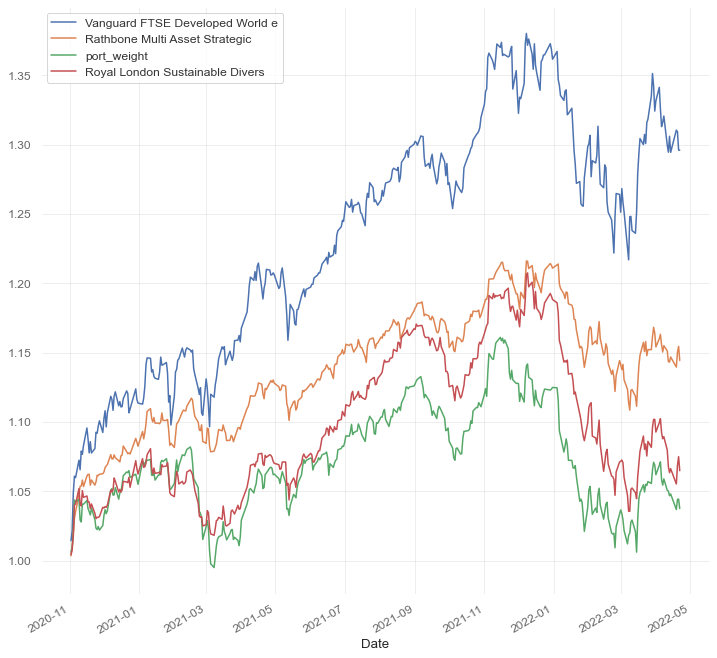

In [66]:
df_retunrs_out_of_sample = myreturns[myreturns.index>='2020-11-01']
pf.timeseries.cum_returns(df_retunrs_out_of_sample[['Vanguard FTSE Developed World e', 'Rathbone Multi Asset Strategic ', 
                                                   'port_weight', 'Royal London Sustainable Divers']], 
                          starting_value=1).plot(figsize=(12,12))

In [ ]:
df_sum_performance

In [ ]:
port_to_test = ['por_HRP_vol_pearson_ledoit_ward', 
                'por_HRP_MV_pearson_ledoit_ward',  
                'por_HRP_MSV_pearson_ledoit_ward', 
                'por_HRP_FLPM_pearson_ledoit_ward']

In [ ]:
df_returns_test = df_retunrs_out_of_sample[(df_retunrs_out_of_sample.index>= '2020-08-01') & (df_retunrs_out_of_sample.index<'2020-11-01') ]

In [ ]:
df_retunrs_out_of_sample

In [ ]:
price_index = ffn.core.to_price_index(df_retunrs_out_of_sample[port_to_test], start=100)
price_index.columns.name 
#ffn.core.PerformanceStats(price_index)
#perf = price_index.calc_stats()
#print(perf.display())

In [ ]:
# check some basic perfomance stats for each asset 
df_stats = ffn.core.GroupStats(price_index).stats
keep_index = ["total_return", "max_drawdown", "calmar",'monthly_sortino']
df_stats[df_stats.index.isin(keep_index)].transpose().sort_values(by=['total_return'], ascending= False)

In [ ]:
rets_dummy = df_returns[df_returns.index>="2019-05-01"]
pf.timeseries.cum_returns(rets_dummy, starting_value=1).plot(figsize=(12,12))